In [39]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import scipy as sc
import seaborn as sns


df = pd.read_csv( 'C:/Users/hp/Downloads/marksheet.csv') 
df.head()

,id,Name,Gender,Age,Section,Science,English,History,Maths
0,1,Bronnie,Female,13,C,21,81,62,49
1,2,Lemmie,Male,15,B,29,41,17,40
2,3,Danya,Female,14,C,12,87,16,96
3,4,Denna,Female,14,B,15,53,82,33
4,5,Jocelin,Male,14,A,43,6,3,21


In [40]:
df.shape

(250, 9)

250 observations , 9 variables

In [41]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       250 non-null    int64 
 1   Name     250 non-null    object
 2   Gender   250 non-null    object
 3   Age      250 non-null    int64 
 4   Section  250 non-null    object
 5   Science  250 non-null    int64 
 6   English  250 non-null    int64 
 7   History  250 non-null    int64 
 8   Maths    250 non-null    int64 
dtypes: int64(6), object(3)
memory usage: 17.7+ KB


In [42]:
df.isna().sum() 

id         0
Name       0
Gender     0
Age        0
Section    0
Science    0
English    0
History    0
Maths      0
dtype: int64

In [43]:
df.duplicated( subset = ('id') ).value_counts()

False    250
Name: count, dtype: int64

In [44]:
df.nunique() 

id         250
Name       247
Gender       2
Age          3
Section      3
Science     91
English     93
History     91
Maths       93
dtype: int64

In [45]:
df[df.duplicated(subset=['Name'], keep = False)].sort_values(by = 'Name')

,id,Name,Gender,Age,Section,Science,English,History,Maths
84,85,Brien,Female,13,C,36,95,55,46
145,146,Brien,Female,15,B,43,4,40,93
198,199,Codi,Male,14,C,30,62,32,60
199,200,Codi,Female,15,A,57,68,56,23
17,18,Dory,Female,13,B,5,89,25,23
167,168,Dory,Female,13,B,23,5,39,42


In [46]:
idx = df[df.duplicated(subset=['Name'])].sort_values(by = 'Name').index

df = df.drop ( labels = idx, axis =0  ) 

In [47]:
df.reset_index( drop = True ) 

df.iloc[145]

id                147
Name       Jaquenette
Gender           Male
Age                15
Section             C
Science            33
English            75
History            98
Maths              84
Name: 146, dtype: object

In [48]:
df.iloc [ idx]  

,id,Name,Gender,Age,Section,Science,English,History,Maths
146,147,Jaquenette,Male,15,C,33,75,98,84
202,203,Norri,Male,14,B,45,21,61,13
169,170,Ermina,Female,15,B,38,17,76,26


In [49]:
df.duplicated( ).sum( )

np.int64(0)

In [50]:
# Category counts 

df['Gender'].value_counts( )

Gender
Male      132
Female    115
Name: count, dtype: int64

In [51]:
df['Section'].value_counts( )

Section
C    92
A    78
B    77
Name: count, dtype: int64

In [52]:
df.groupby( by = 'Section').count()

,id,Name,Gender,Age,Science,English,History,Maths
Section,,,,,,,,
A,78,78,78,78,78,78,78,78
B,77,77,77,77,77,77,77,77
C,92,92,92,92,92,92,92,92


In [53]:
df.describe( )

,id,Age,Science,English,History,Maths
count,247.000000,247.000000,247.000000,247.000000,247.000000,247.000000
mean,124.943320,14.016194,51.566802,48.251012,52.360324,53.020243
std,72.532841,0.821300,29.429580,29.846384,27.006092,27.358869
min,1.000000,13.000000,1.000000,1.000000,1.000000,1.000000
25%,62.500000,13.000000,25.500000,21.000000,31.000000,30.000000
50%,124.000000,14.000000,53.000000,48.000000,53.000000,53.000000
75%,187.500000,15.000000,78.000000,74.000000,76.000000,76.000000
max,250.000000,15.000000,100.000000,100.000000,100.000000,100.000000


In [54]:
#Frequency distribuion 

val = pd.cut ( df['Science'], bins = 5 )
val.value_counts().sort_index() 

Science
(0.901, 20.8]    49
(20.8, 40.6]     45
(40.6, 60.4]     52
(60.4, 80.2]     45
(80.2, 100.0]    56
Name: count, dtype: int64

In [55]:
# Convert the Series into a DataFrame

freq = val.value_counts().sort_index().reset_index() 

# Rename the columns to standard statistical labels
freq.columns = ['Class Interval', 'Frequency']

freq

,Class Interval,Frequency
0,"(0.901, 20.8]",49
1,"(20.8, 40.6]",45
2,"(40.6, 60.4]",52
3,"(60.4, 80.2]",45
4,"(80.2, 100.0]",56


In [56]:
freq ['Relative Frequency'] = freq['Frequency']/freq['Frequency'].sum()  

In [57]:
freq

,Class Interval,Frequency,Relative Frequency
0,"(0.901, 20.8]",49,0.198381
1,"(20.8, 40.6]",45,0.182186
2,"(40.6, 60.4]",52,0.210526
3,"(60.4, 80.2]",45,0.182186
4,"(80.2, 100.0]",56,0.226721


In [58]:
# for math subject

maths = pd.cut( df['Maths'] , bins = 5 ).value_counts().sort_index().reset_index( ) 

maths.columns = ['CI' , 'F'  ] 

maths['RF'] = maths['F'] / maths['F'].sum() 

maths

,CI,F,RF
0,"(0.901, 20.8]",34,0.137652
1,"(20.8, 40.6]",56,0.226721
2,"(40.6, 60.4]",48,0.194332
3,"(60.4, 80.2]",58,0.234818
4,"(80.2, 100.0]",51,0.206478


In [59]:
#Creating congential table

math = pd.cut(df['Maths'], bins=2)
science  = pd.cut(df['Science'], bins=2)


ct = pd.crosstab(math , science , margins = True , normalize = True  , margins_name= 'Total Probability')

ct

Science,"(0.901, 50.5]","(50.5, 100.0]",Total Probability
Maths,,,
"(0.901, 50.5]",0.230769,0.255061,0.48583
"(50.5, 100.0]",0.246964,0.267206,0.51417
Total Probability,0.477733,0.522267,1.00000


In [60]:
#with pandas the table can becomes of 4 cross tab


#with hireachial indexing

history = pd.cut( df['History'] , bins = 2 ) 

english = pd.cut ( df['English'] , bins = 2 ) 

table = pd.crosstab( index = [ math , science ] , columns= [english , history] , normalize = True ) 

table

English                     (0.901, 50.5]               (50.5, 100.0]  \
History                     (0.901, 50.5] (50.5, 100.0] (0.901, 50.5]   
Maths         Science                                                   
(0.901, 50.5] (0.901, 50.5]      0.085020      0.052632      0.044534   
              (50.5, 100.0]      0.052632      0.089069      0.064777   
(50.5, 100.0] (0.901, 50.5]      0.056680      0.068826      0.060729   
              (50.5, 100.0]      0.036437      0.072874      0.080972   

English                                    
History                     (50.5, 100.0]  
Maths         Science                      
(0.901, 50.5] (0.901, 50.5]      0.048583  
              (50.5, 100.0]      0.048583  
(50.5, 100.0] (0.901, 50.5]      0.060729  
              (50.5, 100.0]      0.076923

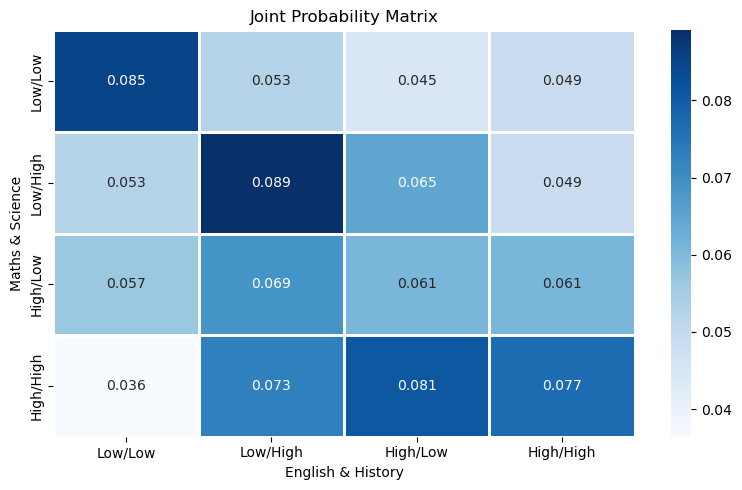

In [61]:
labels = ['Low/Low', 'Low/High', 'High/Low', 'High/High']

plt.figure(figsize=(8, 5))

sns.heatmap(
    table.to_numpy(), 
    annot=True, 
    fmt=".3f", 
    cmap="Blues",          
    linewidths=1,          
    xticklabels=labels,    
    yticklabels=labels     
)

plt.xlabel("English & History")
plt.ylabel("Maths & Science")
plt.title("Joint Probability Matrix")
plt.tight_layout()
plt.show()

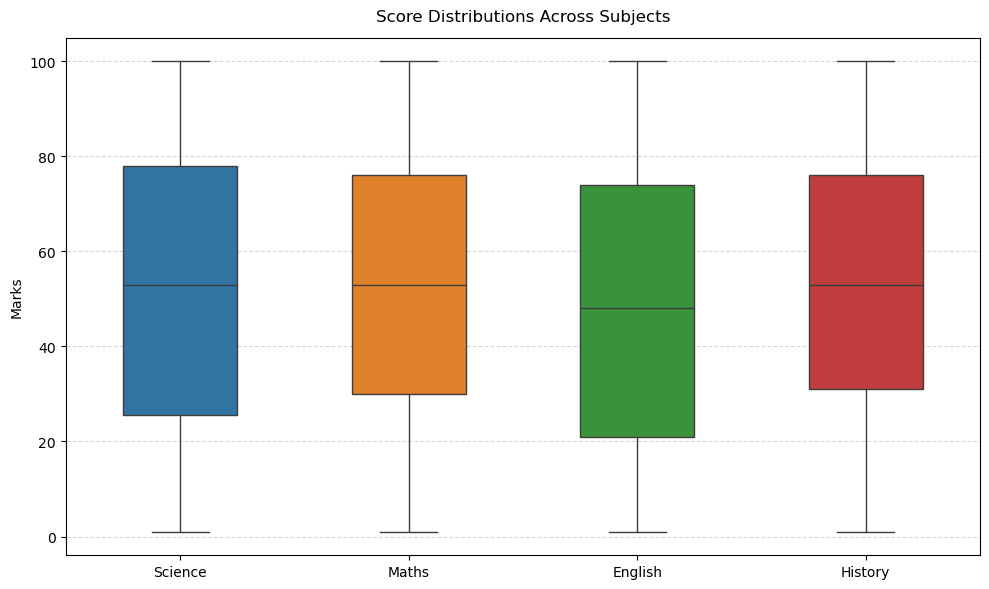

In [62]:
plt.figure(figsize=(10, 6))

subjects = ['Science', 'Maths', 'English', 'History']

# Corrected boxplot call
sns.boxplot(
    data=df[subjects] , width = 0.5
)

plt.title("Score Distributions Across Subjects", fontsize=12, pad=12)
plt.ylabel("Marks", fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

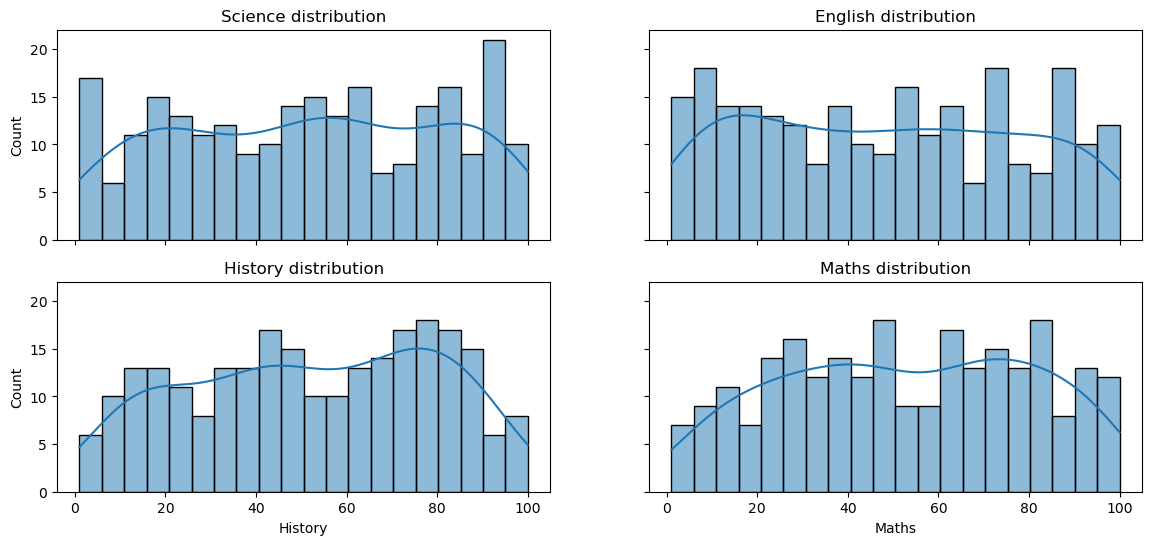

In [63]:
fig , ax  = plt.subplots ( 2,2 , figsize = ( 14,6 ) , sharex = True, sharey = True ) 
ax  = ax.flatten() 
for idx , val  in enumerate ( [5,6,7,8]) :
    sns.histplot( df.iloc [: , val ] , ax = ax[idx] , kde = True ,bins = 20  )
    ax[idx].set_title( f'{df.columns[val]} distribution') 
plt.show() 

In [64]:
df.columns

Index(['id', 'Name', 'Gender', 'Age', 'Section', 'Science', 'English',
       'History', 'Maths'],
      dtype='object')

In [65]:
df

,id,Name,Gender,Age,Section,Science,English,History,Maths
0,1,Bronnie,Female,13,C,21,81,62,49
1,2,Lemmie,Male,15,B,29,41,17,40
2,3,Danya,Female,14,C,12,87,16,96
3,4,Denna,Female,14,B,15,53,82,33
4,5,Jocelin,Male,14,A,43,6,3,21
...,...,...,...,...,...,...,...,...,...
245,246,Nickie,Male,13,C,28,15,25,10
246,247,Rog,Female,13,B,1,4,68,65
247,248,Kaia,Male,15,B,93,48,82,44
248,249,Anni,Female,14,B,35,73,66,59


In [66]:
df = df.set_index  ( ['Gender' , 'Name'] ).sort_index( level = 0 )
df

id  Age Section  Science  English  History  Maths
Gender Name                                                        
Female Adah       39   13       A       71       90       78     35
       Adrianne  149   15       C       51       67       67     91
       Ailene    137   15       C       52       39       37      3
       Alard     164   13       A       91       12       15     70
       Aldin     158   13       C       72       24       83     62
...              ...  ...     ...      ...      ...      ...    ...
Male   Vaughn    109   14       C       11       30       83     17
       Vinny      49   13       B       81       25       99     13
       Vivyan    211   14       A       28       30       80     33
       Woodie    104   15       A       37       57       48     75
       Zack      218   13       B       72       46       40     90

[247 rows x 7 columns]

In [67]:

df['Average'] = df[ ['Science', 'English', 'History', 'Maths'] ].mean(axis=1)

df

id  Age Section  Science  English  History  Maths  Average
Gender Name                                                                 
Female Adah       39   13       A       71       90       78     35    68.50
       Adrianne  149   15       C       51       67       67     91    69.00
       Ailene    137   15       C       52       39       37      3    32.75
       Alard     164   13       A       91       12       15     70    47.00
       Aldin     158   13       C       72       24       83     62    60.25
...              ...  ...     ...      ...      ...      ...    ...      ...
Male   Vaughn    109   14       C       11       30       83     17    35.25
       Vinny      49   13       B       81       25       99     13    54.50
       Vivyan    211   14       A       28       30       80     33    42.75
       Woodie    104   15       A       37       57       48     75    54.25
       Zack      218   13       B       72       46       40     90    62.00

[247 rows x 8 columns]

In [68]:
df.loc[ [df['Average'].idxmax()] ]

,,id,Age,Section,Science,English,History,Maths,Average
Gender,Name,,,,,,,,
Male,Dunn,11,15,C,100,93,87,81,90.25


In [69]:
df.groupby('Gender')['Average'].max() 

Gender
Female    86.75
Male      90.25
Name: Average, dtype: float64

In [70]:

df.groupby('Gender')[['Science', 'English', 'History', 'Maths', 'Average']].mean()



,Science,English,History,Maths,Average
Gender,,,,,
Female,51.173913,51.286957,50.852174,50.304348,50.904348
Male,51.909091,45.606061,53.674242,55.386364,51.643939


In [71]:

df.groupby('Section')[['Science', 'English', 'History', 'Maths', 'Average']].agg(['mean' , 'std'])

Science               English               History             \
              mean        std       mean        std       mean        std   
Section                                                                     
A        53.833333  28.221948  50.320513  31.205017  51.871795  27.435572   
B        54.610390  29.111020  48.428571  30.152869  53.675325  26.277087   
C        47.097826  30.449764  46.347826  28.591644  51.673913  27.493100   

             Maths               Average             
              mean        std       mean        std  
Section                                              
A        52.282051  27.343841  52.076923  14.633971  
B        54.948052  27.503539  52.915584  14.480398  
C        52.032609  27.466844  49.288043  15.518331

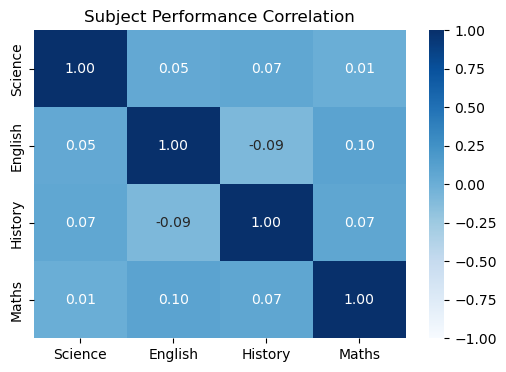

In [72]:
corr_matrix = df[['Science', 'English', 'History', 'Maths']].corr()


plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', vmin=-1, vmax=1, fmt='.2f')
plt.title('Subject Performance Correlation')
plt.show()

In [73]:
bins = [0, 40, 60, 80, 100]
grade_labels = ['Fail', 'Pass', 'Merit', 'Distinction']

df['Performance_Tier'] = pd.cut(df['Average'], bins=bins, labels=grade_labels) 

df


                                

id  Age Section  Science  English  History  Maths  Average  \
Gender Name                                                                    
Female Adah       39   13       A       71       90       78     35    68.50   
       Adrianne  149   15       C       51       67       67     91    69.00   
       Ailene    137   15       C       52       39       37      3    32.75   
       Alard     164   13       A       91       12       15     70    47.00   
       Aldin     158   13       C       72       24       83     62    60.25   
...              ...  ...     ...      ...      ...      ...    ...      ...   
Male   Vaughn    109   14       C       11       30       83     17    35.25   
       Vinny      49   13       B       81       25       99     13    54.50   
       Vivyan    211   14       A       28       30       80     33    42.75   
       Woodie    104   15       A       37       57       48     75    54.25   
       Zack      218   13       B       72       46       40     90    62.00   

                Performance_Tier  
Gender Name                       
Female Adah                Merit  
       Adrianne            Merit  
       Ailene               Fail  
       Alard                Pass  
       Aldin               Merit  
...                          ...  
Male   Vaughn               Fail  
       Vinny                Pass  
       Vivyan               Pass  
       Woodie               Pass  
       Zack                Merit  

[247 rows x 9 columns]

In [74]:
df = df.sort_values('Average' , ascending = False ) 
df =df.reset_index( )

df

,Gender,Name,id,Age,Section,Science,English,History,Maths,Average,Performance_Tier
0,Male,Dunn,11,15,C,100,93,87,81,90.25,Distinction
1,Male,Patrizia,121,13,A,79,88,96,93,89.00,Distinction
2,Female,Nil,69,15,A,84,97,70,96,86.75,Distinction
3,Female,Daffi,92,15,A,79,82,99,81,85.25,Distinction
4,Female,Ruddie,201,15,B,84,97,88,64,83.25,Distinction
...,...,...,...,...,...,...,...,...,...,...,...
242,Male,Berget,138,13,C,10,29,21,13,18.25,Fail
243,Male,Jocelin,5,14,A,43,6,3,21,18.25,Fail
244,Female,Blake,226,15,B,16,4,49,1,17.50,Fail
245,Male,Ashlan,20,13,B,41,6,17,3,16.75,Fail


In [75]:
df = df.set_index ('Name')
df

,Gender,id,Age,Section,Science,English,History,Maths,Average,Performance_Tier
Name,,,,,,,,,,
Dunn,Male,11,15,C,100,93,87,81,90.25,Distinction
Patrizia,Male,121,13,A,79,88,96,93,89.00,Distinction
Nil,Female,69,15,A,84,97,70,96,86.75,Distinction
Daffi,Female,92,15,A,79,82,99,81,85.25,Distinction
Ruddie,Female,201,15,B,84,97,88,64,83.25,Distinction
...,...,...,...,...,...,...,...,...,...,...
Berget,Male,138,13,C,10,29,21,13,18.25,Fail
Jocelin,Male,5,14,A,43,6,3,21,18.25,Fail
Blake,Female,226,15,B,16,4,49,1,17.50,Fail


In [76]:
df.set_index( ['Gender'] ).groupby('Gender')['Performance_Tier'].value_counts().sort_index( ).unstack( ) 

Performance_Tier,Fail,Pass,Merit,Distinction
Gender,,,,
Female,30,54,28,3
Male,27,63,40,2


In [83]:
df.set_index( ['Gender'] ).groupby('Section')['Performance_Tier'].value_counts().sort_index( ).unstack( ) 

Performance_Tier,Fail,Pass,Merit,Distinction
Section,,,,
A,17,38,20,3
B,14,37,25,1
C,26,42,23,1


In [81]:
df['Performance_Tier'].value_counts( ) 

Performance_Tier
Pass           117
Merit           68
Fail            57
Distinction      5
Name: count, dtype: int64

In [78]:
df.to_csv('modified.csv') 